<a href="https://colab.research.google.com/github/SebTics/SebTics/blob/main/Analisis_Funding_Agencies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analísis Exploratorio (Funding Agencies)


El analísis exploratorio de datos es un paso clave en la ciencia de datos y en el presente proyecto, con ello podremos entender los datos que tenemos y ver como manejarlos.
  

A continuación nos enfocamos en el apartado de Funding Agencies, con infoirmación sobre los artículos de investigación y las agencias que fundan estos artículos, tenemos información general y específica de los artículos mencionados, citados, y podremos después identificar ciertas relaciones, patrones, etc, que nos ayudarán en los próximos pasos del proyecto.

In [2]:
# Sirve para que no salgan los warnings de tipo FutureWarning, para algunas graficas de matplotlib
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Datset Locations

In [3]:
# pandas se utiliza para manipulación de datos y lectura de los datos
import pandas as pd

In [5]:
# Cargar los datos
df = pd.read_csv("Incites Funding Agencies.csv")
# Mostar los primeros 5 registros
df.head()

,Name,Web of Science Documents,Times Cited,Rank,% Docs Cited,Category Normalized Citation Impact,% Global Baseline (Docs),% First Author (2008-2023),% Documents in Top 1%,% International Collaborations,...,H-Index,% All Open Access Documents,Citations From Patents,% Gold Documents,% Documents in Q1 Journals,% Gold - Hybrid Documents,% Documents in Q2 Journals,% Free to Read Documents,% Documents in Q3 Journals,% Documents in Q4 Journals
0,Global Baseline,72797019.0,1.305463e+09,NaN,65.95,0.984205,100.000000,NaN,1.16,14.77,...,3560.0,23.68,16213376.0,7.24,47.51,3.53,24.54,6.57,15.35,12.61
1,Baseline for All Items,124895.0,2.879185e+06,NaN,90.74,1.097617,NaN,NaN,1.48,54.35,...,447.0,46.60,11436.0,20.63,44.25,6.65,29.93,7.85,16.93,8.89
2,Consejo Nacional de Ciencia y Tecnologia (CONA...,84079.0,1.318129e+06,1.0,89.85,0.769962,0.115498,86.78,0.62,39.10,...,239.0,40.68,3898.0,21.05,39.00,4.86,31.74,5.89,19.03,10.23
3,United States Department of Health & Human Ser...,8362.0,5.026850e+05,2.0,97.01,2.223847,0.011487,30.19,4.23,94.69,...,266.0,75.21,4738.0,20.84,66.38,10.36,22.16,15.80,8.62,2.84
4,National Institutes of Health (NIH) - USA,8173.0,4.941840e+05,3.0,96.95,2.238146,0.011227,30.10,4.27,94.78,...,263.0,75.46,4700.0,20.75,66.54,10.41,22.09,15.75,8.59,2.78


# Analísis de la base

In [6]:
# Cantidad total de observaciones
print("Cantidad total de observaciones: ", df.shape[0])

Cantidad total de observaciones:  883


# Columnas e Instancias

In [7]:
# Cantidad de columnas e instancias
num_columns = df.shape[1]
num_instances = df.shape[0]
print(f"Cantidad de columnas: {num_columns}")
print(f"Cantidad de instancias: {num_instances}")

# Tipo de dato de cada columna
data_types = df.dtypes
data_types

Cantidad de columnas: 33
Cantidad de instancias: 883


Name                                    object
Web of Science Documents               float64
Times Cited                            float64
Rank                                   float64
% Docs Cited                           float64
Category Normalized Citation Impact    float64
% Global Baseline (Docs)               float64
% First Author (2008-2023)             float64
% Documents in Top 1%                  float64
% International Collaborations         float64
% Global Baseline (Cites)              float64
% Last Author (2008-2023)              float64
% Documents in Top 10%                 float64
% Industry Collaborations              float64
% Baseline for All Items (Docs)        float64
% Corresponding Author (2008-2023)     float64
% Highly Cited Papers                  float64
% Baseline for All Items (Cites)       float64
Country or Region                       object
Average Percentile                     float64
% Hot Papers                           float64
% Domestic Co

# Cantidad de columnas por tipo de dato

In [8]:
# Cantidad de columnas por tipo de dato
data_types.value_counts()

float64    31
object      2
Name: count, dtype: int64

Podemos ver que las columnas de nuestra base de datos contienen dos diferentes tipos de datos: float64 y object, para llevar a cabo un análisis de los datos adecuado, requerimos que las columnas presentes tengan el tipo de dato correcto.
Nosotros sabemos que el tipo object es usado para almacenar texto y el tipo floaa64 es utilizado para almacenar números decimales.

## Cantidad de Columnas e Instancias y Tipo de Dato de Cada Columna

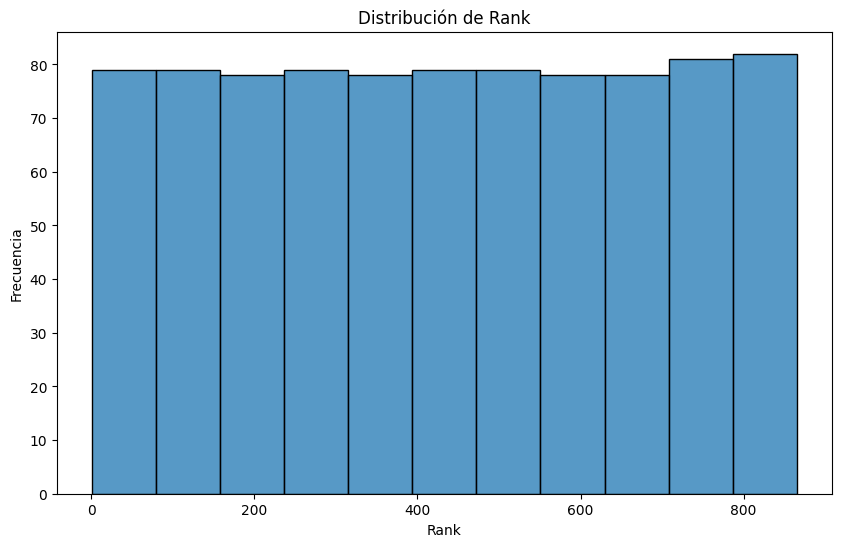

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df["Rank"], bins="auto")
plt.title("Distribución de Rank")
plt.xlabel("Rank")
plt.ylabel("Frecuencia")
plt.show()

# Identificación de valores faltantes

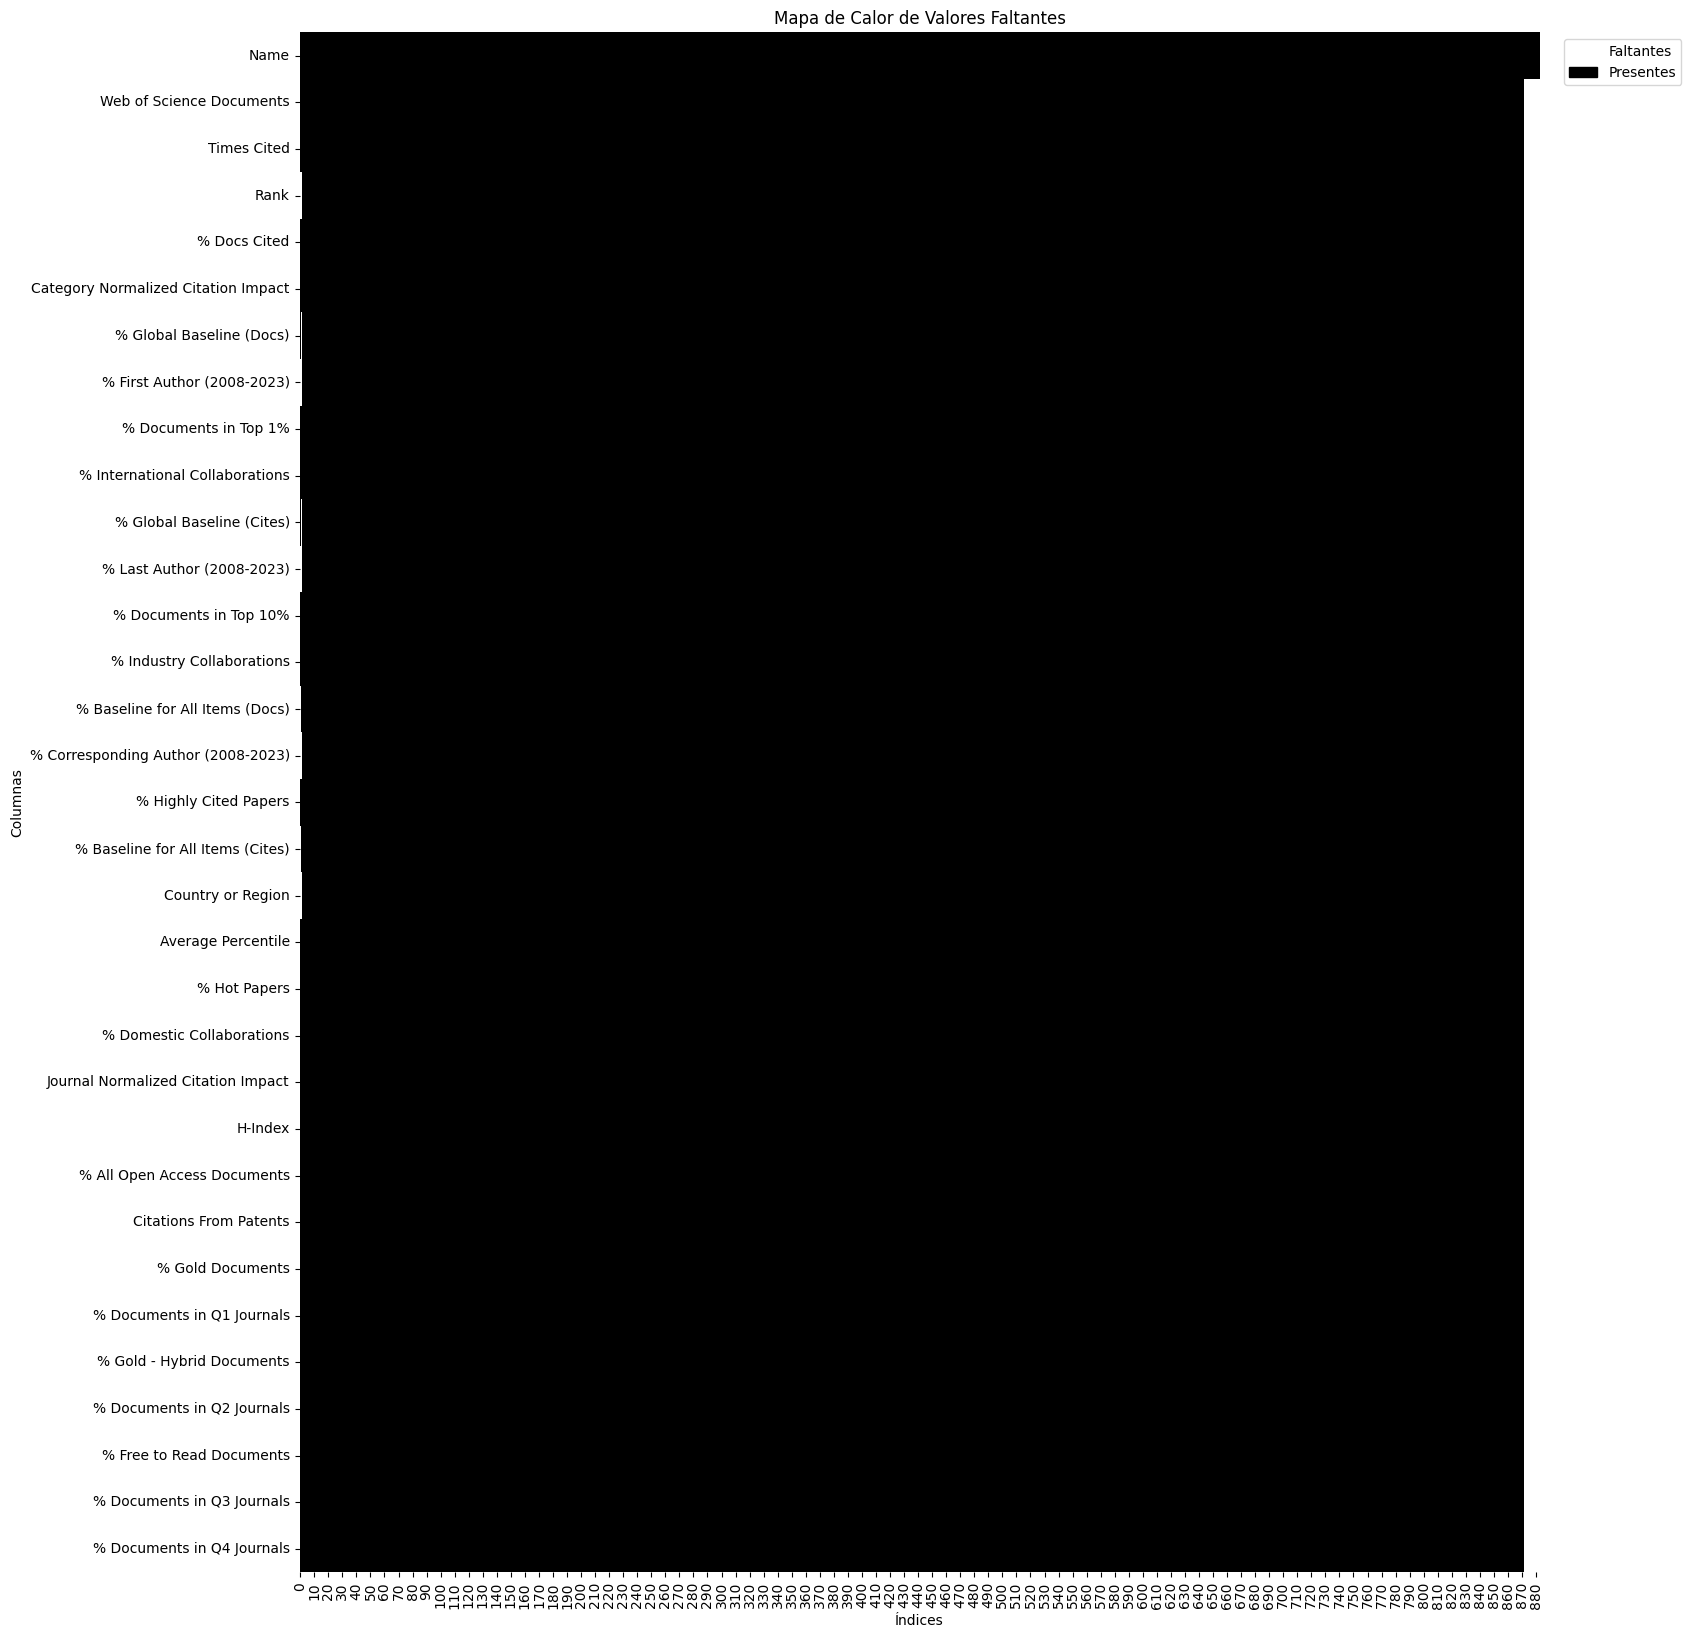

In [10]:
import matplotlib.patches as mpatches

# Mapa de calor invertido con todas las columnas y leyenda
plt.figure(figsize=(16, 20))
sns.heatmap(df.isnull().transpose(), cbar=False, cmap="binary_r", yticklabels=True)
plt.title("Mapa de Calor de Valores Faltantes")
plt.xlabel("Índices")
plt.ylabel("Columnas")

# Añadir leyenda
legend_labels = [
    mpatches.Patch(color="white", label="Faltantes"),
    mpatches.Patch(color="black", label="Presentes"),
]
plt.legend(handles=legend_labels, loc="upper right", bbox_to_anchor=(1.12, 1))
plt.show()

La grafica anterior muestra los datos faltantes por columna, los valores faltantes se muestran en blanco y los valores presentes en negro.
Podemos notar que en prácticamente no contamos con datos faltantes en cantidades grande, aunque en las columnas de "Web of Science Documents" hasta "Documents in Q4 journals" hay algunos datos faltantes para la filas 880.

Vamos a imprimir los datos exactos para tener presente los datos faltantes de cada columna y no solo quedarnos con la visualizacion.

In [11]:
# Cantidad de valores faltantes por columna
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
# Imprimir cantidad de valores faltantes
print(missing_values)

Web of Science Documents               11
Times Cited                            11
Rank                                   13
% Docs Cited                           11
Category Normalized Citation Impact    11
% Global Baseline (Docs)               12
% First Author (2008-2023)             13
% Documents in Top 1%                  11
% International Collaborations         11
% Global Baseline (Cites)              12
% Last Author (2008-2023)              13
% Documents in Top 10%                 11
% Industry Collaborations              11
% Baseline for All Items (Docs)        12
% Corresponding Author (2008-2023)     13
% Highly Cited Papers                  11
% Baseline for All Items (Cites)       12
Country or Region                      13
Average Percentile                     11
% Hot Papers                           11
% Domestic Collaborations              11
Journal Normalized Citation Impact     11
H-Index                                11
% All Open Access Documents       

Sabemos, tenemos 883 observaciones en total. Ahora veamos el porcentaje de datos faltantes que tenemos en comparacion para cada columna.

In [12]:
#  Porcentaje de valores faltantes por columna
missing_values_percentage = missing_values / num_instances * 100
# Imprimir porcentaje de valores faltantes
print(missing_values_percentage)

Web of Science Documents               1.245753
Times Cited                            1.245753
Rank                                   1.472254
% Docs Cited                           1.245753
Category Normalized Citation Impact    1.245753
% Global Baseline (Docs)               1.359003
% First Author (2008-2023)             1.472254
% Documents in Top 1%                  1.245753
% International Collaborations         1.245753
% Global Baseline (Cites)              1.359003
% Last Author (2008-2023)              1.472254
% Documents in Top 10%                 1.245753
% Industry Collaborations              1.245753
% Baseline for All Items (Docs)        1.359003
% Corresponding Author (2008-2023)     1.472254
% Highly Cited Papers                  1.245753
% Baseline for All Items (Cites)       1.359003
Country or Region                      1.472254
Average Percentile                     1.245753
% Hot Papers                           1.245753
% Domestic Collaborations              1

Observese que todas las columnas con datos faltantes tienen un porcentaje de valores faltantes mayor al 1% pero menor al 1.5%.
A mi consideración no requerimos limpiar la base de datos con estos porcentajes dados, mucho menos eliminar columnas, esto no debería afectarnos en el futuro.



# Rango de las columnas

In [13]:
# Obtener columnas numéricas
numeric_cols = df.select_dtypes(include=["number"]).columns

# Calcular y mostrar rangos
ranges = df[numeric_cols].agg(["min", "max"])
ranges

,Web of Science Documents,Times Cited,Rank,% Docs Cited,Category Normalized Citation Impact,% Global Baseline (Docs),% First Author (2008-2023),% Documents in Top 1%,% International Collaborations,% Global Baseline (Cites),...,H-Index,% All Open Access Documents,Citations From Patents,% Gold Documents,% Documents in Q1 Journals,% Gold - Hybrid Documents,% Documents in Q2 Journals,% Free to Read Documents,% Documents in Q3 Journals,% Documents in Q4 Journals
min,1.0,0.000000e+00,1.0,0.0,0.0000,0.000001,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,72797019.0,1.305463e+09,865.0,100.0,79.0467,100.000000,100.0,100.0,100.0,100.0,...,3560.0,100.0,16213376.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


Identificamos que las variables dentro del conjunto de datos presentan rangos de valores que son
significativamente distintos entre sí.
 Esta disparidad de rangos podrían afectar el rendimiento de
los algoritmos de aprendizaje automático, ya que algunos algoritmos pueden ser sensibles a la
 escala de las variables.

# Matriz de Correlación

La matriz se aplica a las variables numéricas, ya que la correlación es una medida de la relación lineal entre dos variables continuas. Aquí nuestras variables 'object' no seran contadas, pues ocupamos unicamente valores numéricos.

## Matriz de correlación (codigo simple y rápido)

In [14]:
# Obtener columnas categóricas, para saber cuales quitar
categorical_cols = df.select_dtypes(include=["object"]).columns

# Quedarse con las columnas numéricas solamente, pero no asignar a df
# La variable numeric_cols la obtuvimos en un paso anterior.
df_numeric = df[numeric_cols]

In [15]:
# Imprimir la cantidad de columnas numéricas
print(f"Cantidad de columnas numéricas: {df_numeric.shape[1]}")

Cantidad de columnas numéricas: 31


# Matriz con pandas

In [16]:
# Matriz de correlación usando pandas
correlation_matrix = df_numeric.corr()
# Mostrar matriz de correlación
correlation_matrix

,Web of Science Documents,Times Cited,Rank,% Docs Cited,Category Normalized Citation Impact,% Global Baseline (Docs),% First Author (2008-2023),% Documents in Top 1%,% International Collaborations,% Global Baseline (Cites),...,H-Index,% All Open Access Documents,Citations From Patents,% Gold Documents,% Documents in Q1 Journals,% Gold - Hybrid Documents,% Documents in Q2 Journals,% Free to Read Documents,% Documents in Q3 Journals,% Documents in Q4 Journals
Web of Science Documents,1.000000,1.000000,-0.181670,-0.100770,-0.016468,1.000000,0.133268,-0.018941,-0.273433,1.000000,...,0.942232,-0.062272,0.999999,-0.023345,-0.027008,-0.025583,0.007608,-0.013495,0.016515,0.030682
Times Cited,1.000000,1.000000,-0.401032,-0.100749,-0.016432,1.000000,0.076434,-0.018930,-0.273447,1.000000,...,0.942458,-0.062177,0.999998,-0.023309,-0.026939,-0.025492,0.007568,-0.013497,0.016473,0.030655
Rank,-0.181670,-0.401032,1.000000,-0.119814,-0.240041,-0.181670,0.036742,-0.169347,0.023481,-0.401032,...,-0.794302,-0.275994,-0.234006,-0.020393,-0.305677,-0.248231,0.190014,-0.092678,0.171841,0.105173
% Docs Cited,-0.100770,-0.100749,-0.119814,1.000000,0.082037,-0.100776,-0.072161,0.100483,0.086847,-0.100747,...,-0.076841,0.042367,-0.100731,0.036775,0.179677,0.010059,-0.039673,-0.090844,-0.111247,-0.115254
Category Normalized Citation Impact,-0.016468,-0.016432,-0.240041,0.082037,1.000000,-0.016461,-0.166175,0.633765,0.066736,-0.016417,...,-0.020374,0.163953,-0.016416,-0.122233,0.214312,0.279728,-0.161103,0.064390,-0.077522,-0.091424
% Global Baseline (Docs),1.000000,1.000000,-0.181670,-0.100776,-0.016461,1.000000,0.133268,-0.018934,-0.276112,1.000000,...,0.947929,-0.062287,1.000000,-0.023344,-0.027004,-0.025577,0.007600,-0.013490,0.016507,0.030677
% First Author (2008-2023),0.133268,0.076434,0.036742,-0.072161,-0.166175,0.133268,1.000000,-0.210511,-0.482960,0.076434,...,-0.021478,-0.227819,0.098777,-0.083608,-0.194087,-0.183533,0.058835,-0.025085,0.168797,0.153061
% Documents in Top 1%,-0.018941,-0.018930,-0.169347,0.100483,0.633765,-0.018934,-0.210511,1.000000,0.084042,-0.018914,...,-0.023418,0.188186,-0.018889,-0.144044,0.301382,0.256166,-0.222769,0.136112,-0.132589,-0.107002
% International Collaborations,-0.273433,-0.273447,0.023481,0.086847,0.066736,-0.276112,-0.482960,0.084042,1.000000,-0.276058,...,-0.286685,0.160779,-0.273074,0.062472,0.194177,0.108438,-0.086829,-0.045408,-0.163217,-0.090617
% Global Baseline (Cites),1.000000,1.000000,-0.401032,-0.100747,-0.016417,1.000000,0.076434,-0.018914,-0.276058,1.000000,...,0.948103,-0.062177,0.999999,-0.023306,-0.026920,-0.025476,0.007552,-0.013487,0.016455,0.030641


# Matriz mas visual

<Axes: title={'center': 'Matriz de Correlación'}>

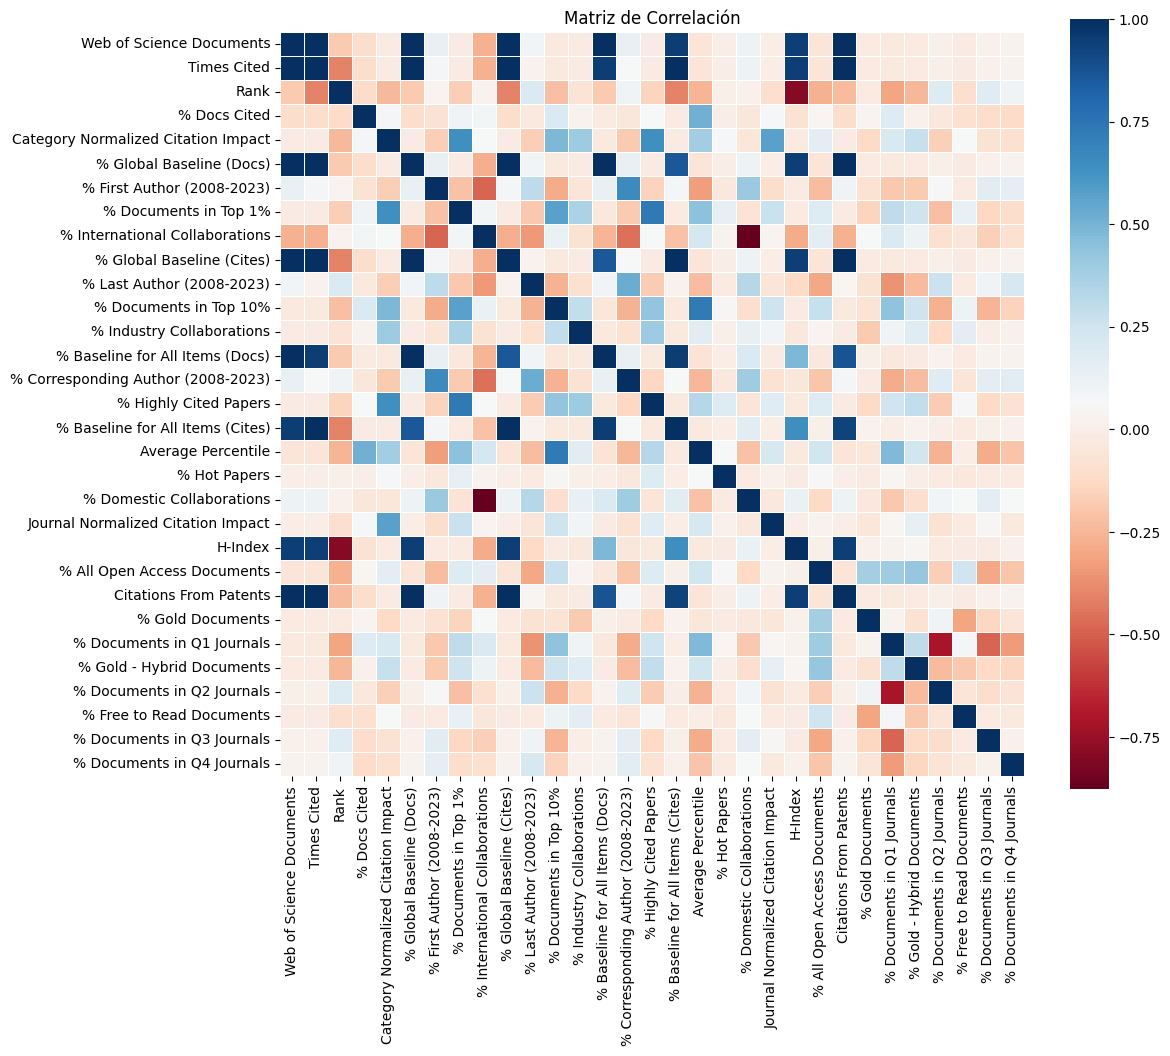

In [17]:
# Visualización de la matriz de correlación
plt.figure(figsize=(12, 10))
plt.title("Matriz de Correlación")
# Add heatmap with grid
sns.heatmap(
    correlation_matrix,  # Matriz de correlación
    cmap="RdBu",  # Color con gradiente de rojo a azul
    annot=False,  # No mostrar valores en las celdas, se puede cambiar a True
    square=True,  # Hacer los cuadrados iguales
    linecolor="white",  # Color de las líneas que separan las celdas
    linewidths=0.5,  # Grosor de las líneas que separan las celdas
)

Vemos en la img anterior la matriz de correlación de forma visual. Los colores representan el grado de correlación entre
las variables, los tonos más oscuros indican una correlación fuerte y negativa. Por otro lado, los tonos más claros indican una correlación
fuerte y positiva. La diagonal principal, que se muestra en blanco, representa la correlación de cada variable consigo misma,
que siempre es igual a 1. Los tonos morados representan una correlación negativa, mientras que los tonos naranjas representan una correlación positiva.

## Correlación de variables numéricas usando agrupación

Esta correlación agrupada es una forma de organizar la matriz de correlación para identificar patrones y relaciones entre las variables. En este caso, las variables se agrupan según su correlación, lo que facilita la identificación de patrones y relaciones entre las variables. Por ejemplo, las variables que tienen una alta correlación positiva se agrupan juntas, mientras que las variables con una alta correlación negativa se agrupan en otro grupo.

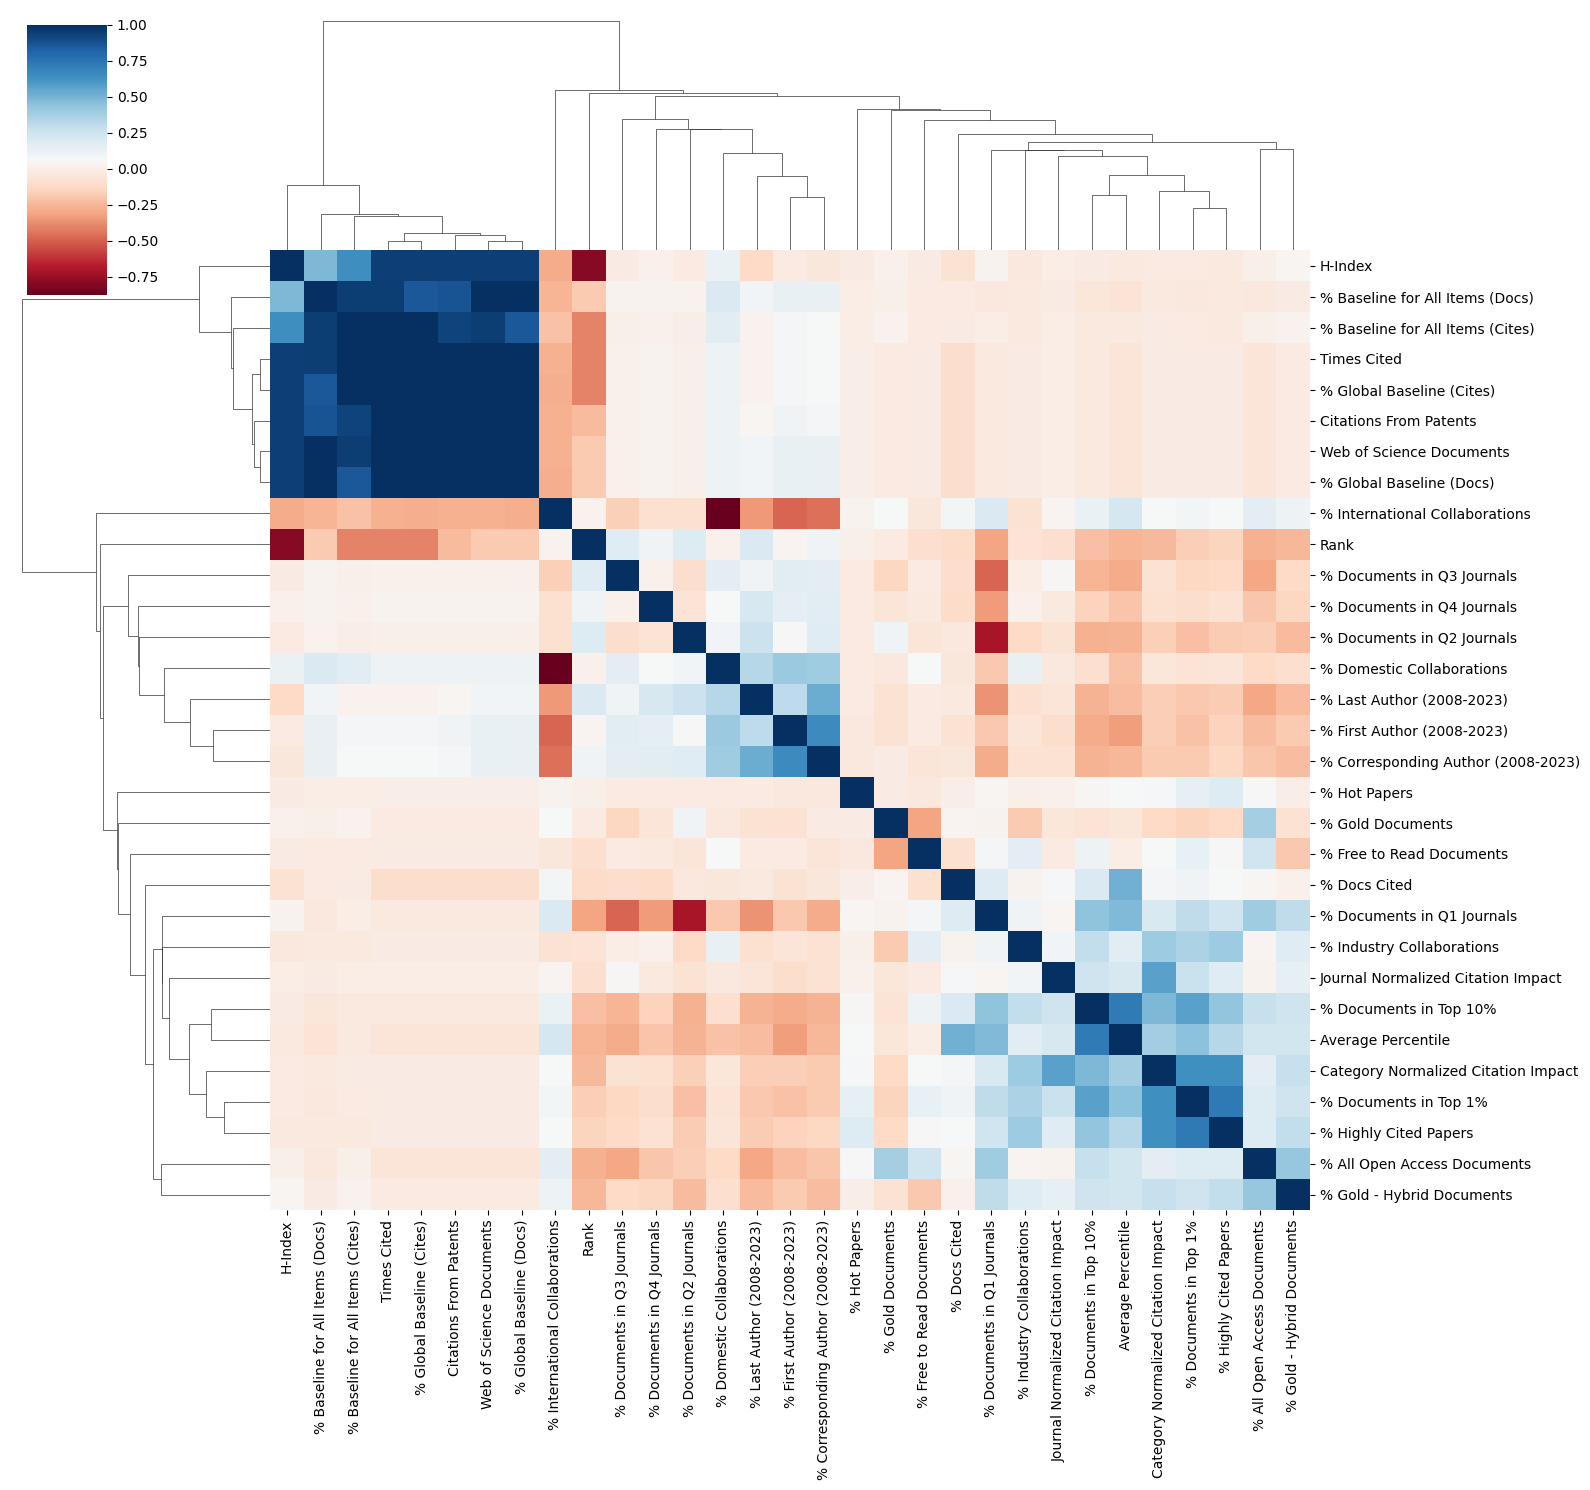

In [18]:
sns.clustermap(
    correlation_matrix, cmap="RdBu", method="single", figsize=(16, 15)  # Método de agrupamiento
)

La matriz de correlación es una herramienta crucial para comprender las variables y sus relaciones. Con ella nos permite identificar las relaciones más fuertes con la variable de interés, que en este caso es 'Web of Science Documents'. Al analizar la matriz, destacamos que las variables 'Times cited', 'Global Baseline (Cities)', 'Citations from Patents' y 'Global baseline' presentan correlaciones significativas con nuestra variable de interes.

## Grafica de barras de correlacion entre todas las variables y 'Web of Science Socuments'

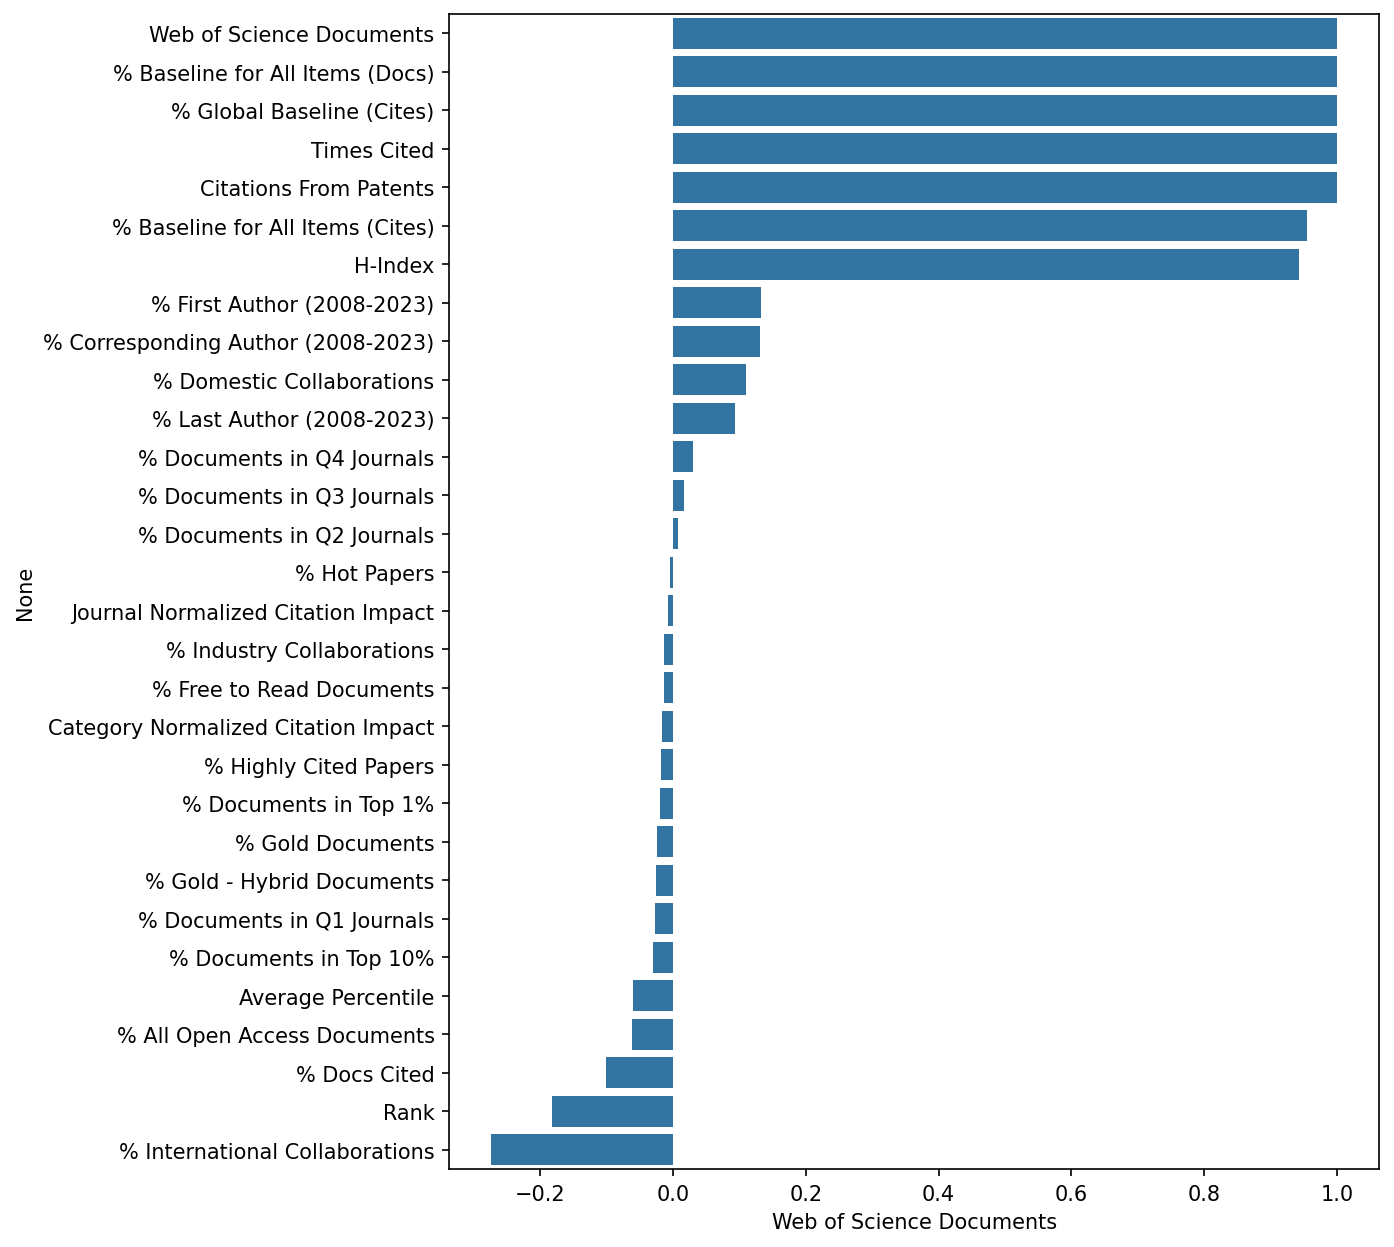

In [19]:
corr = correlation_matrix.sort_values("Web of Science Documents", ascending=False)
plt.figure(figsize=(8, 10), dpi=150)
sns.barplot(x=corr["Web of Science Documents"][1:], y=corr.index[1:], orient="h")
plt.show()

Esta gráfica muestra la correlación entre todas las variables y 'Web of Science Documents'. Nótese que las barras verticales representan la fuerza de la correlación, las barras más largas indican una correlación más fuerte. Por otro lado, las barras más cortas indican una correlación más débil. Esta visualización es útil para identificar las variables que tienen una correlación significativa con 'Web of Science Documents', esta puede resultar útil para la selección de variables en el proceso de modelado.

## Relación de Web of Science Documents con variables numericas

Diagrama de dispersión de los documentos con su ranking.

<Axes: xlabel='Web of Science Documents', ylabel='Times Cited'>

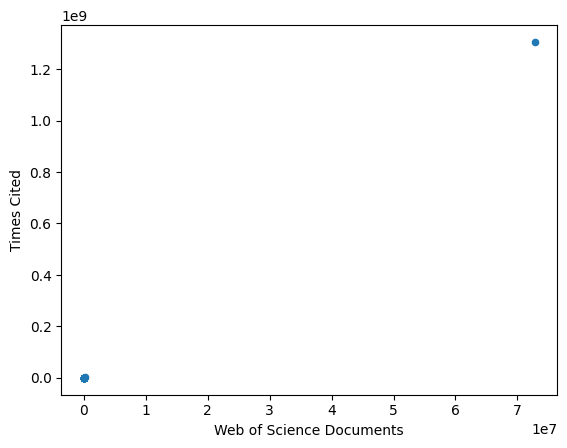

In [20]:
# Diagrama de disperción Rank / Web of science documents
data = pd.concat([df["Web of Science Documents"], df["Times Cited"]], axis=1)
data.plot.scatter(x="Web of Science Documents", y="Times Cited")

Diagra de dispersión con los documentos que llegaron al top 1.

<Axes: xlabel='Web of Science Documents', ylabel='Average Percentile'>

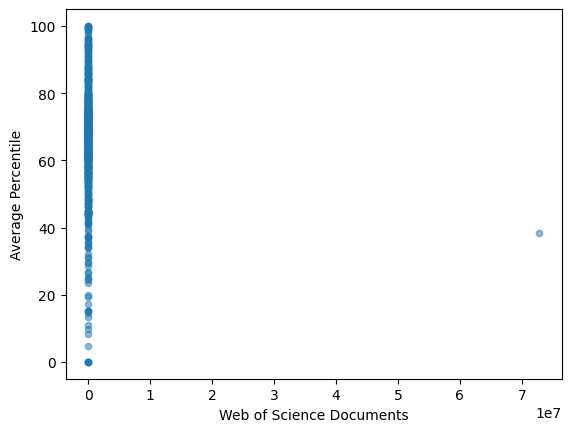

In [21]:
# Diagrama de disperción Documents in Top 10/ Web of science documents
data = pd.concat([df["Web of Science Documents"], df["Average Percentile"]], axis=1)
data.plot.scatter(x="Web of Science Documents", y="Average Percentile", alpha=0.5)

# Relación con variables categoricas

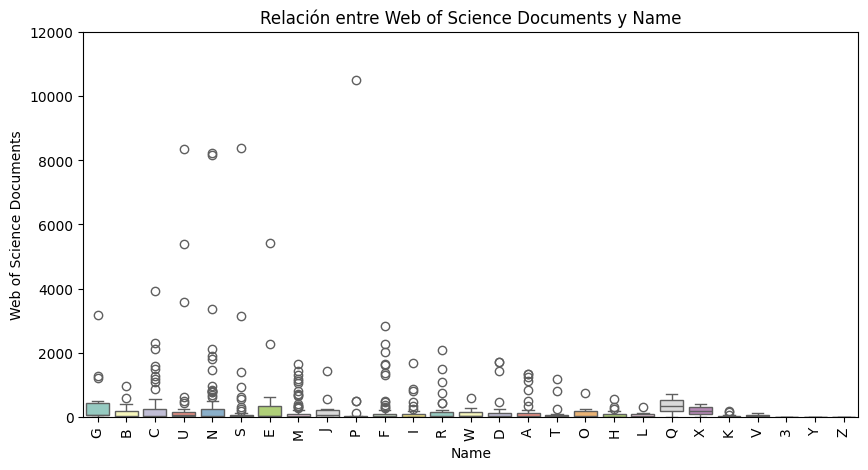

,Name,Short Name
0,Global Baseline,G
1,Baseline for All Items,B
2,Consejo Nacional de Ciencia y Tecnologia (CONA...,C
3,United States Department of Health & Human Ser...,U
4,National Institutes of Health (NIH) - USA,N
...,...,...
878,Funding Data Source: All Sources,F
879,Researcher Location: [MEXICO],R
880,Funding Output Type: Funded,F
881,"Exported date Feb 20, 2024.",E


In [22]:
# Crear una nueva columna con solo las primeras dos letras de cada nombre
df['Short Name'] = df['Name'].apply(lambda x: x[:1])

# Diagrama de web of science documents por Name
data = pd.concat([df["Web of Science Documents"], df["Short Name"]], axis=1)
f, ax = plt.subplots(figsize=(10, 5))
fig = sns.boxplot(x="Short Name", y="Web of Science Documents", data=data, palette="Set3")
fig.axis(ymin=0, ymax=12000)
plt.title("Relación entre Web of Science Documents y Name")
plt.xlabel("Name")
plt.ylabel("Web of Science Documents")
plt.xticks(rotation=90)  # Cambia el ángulo de rotación aquí
plt.show()

# Imprimimos todas las columnas de short name y a que valor de Name corresponde
df[['Name', 'Short Name']]



A continuación, incluimos algunos otros gráficos para visualizar datos por ranking, como top 10, para darnos una idea de las Funding Agencies a las que tenemos que prestar mas atención en general.

# Top 10 Funding Agencies


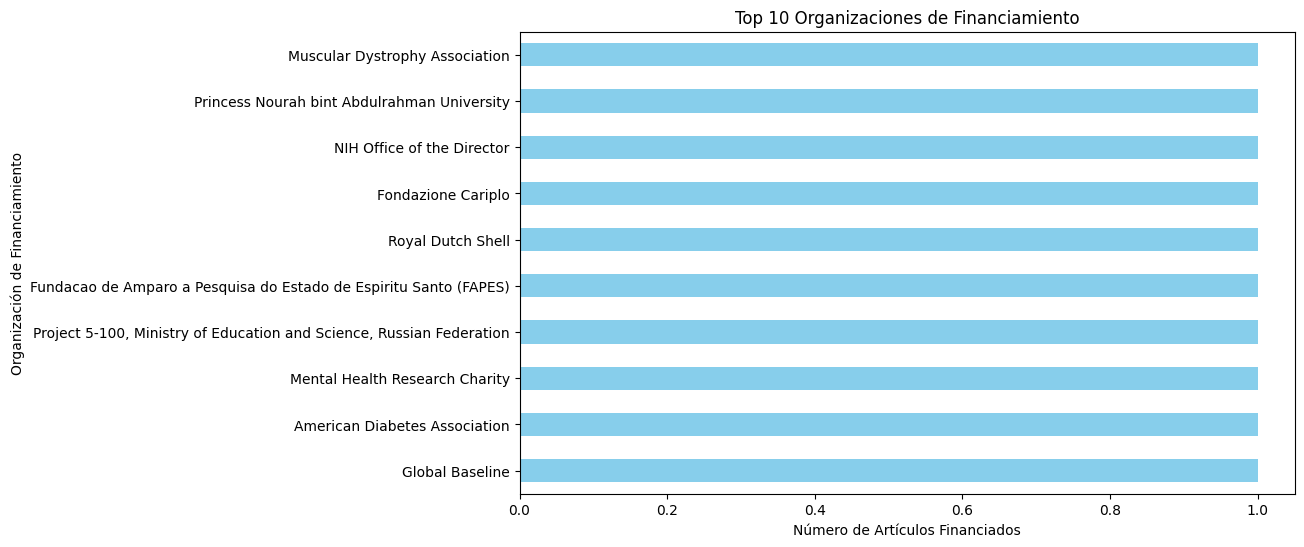

In [23]:
# Calcular las 10 organizaciones principales
top_10_organizations = df["Name"].value_counts().head(10)

# Crear el gráfico de barras horizontales
plt.figure(figsize=(10, 6))
top_10_organizations.sort_values().plot(kind="barh", color="skyblue")
plt.title("Top 10 Organizaciones de Financiamiento")
plt.xlabel("Número de Artículos Financiados")
plt.ylabel("Organización de Financiamiento")
plt.show()

# Artículos Financiados por el top 10 organizaciones principales


<Figure size 1000x600 with 0 Axes>

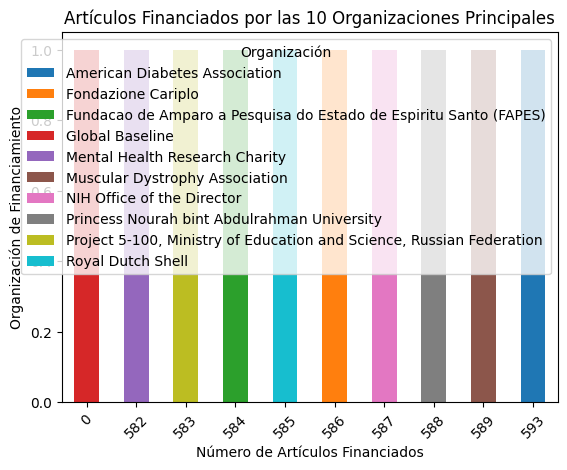

In [25]:
# Filtrar el DataFrame para incluir solo las 10 organizaciones principales
top_10_organizations = df["Name"].value_counts().head(10).index
df_top_10 = df[df["Name"].isin(top_10_organizations)]

# Calcular la cantidad de artículos financiados por cada organización
organizaciones_frecuencia = df_top_10["Name"].value_counts()

# Pivotar los datos para tener las organizaciones de financiamiento como columnas
df_pivot = df_top_10.pivot_table(index=df_top_10.index, columns="Name", aggfunc='size', fill_value=0)

# Crear el gráfico de barras apiladas
plt.figure(figsize=(10, 6))
df_pivot.plot(kind="bar", stacked=True, color=sns.color_palette("tab10", len(df_pivot.columns)))
plt.title("Artículos Financiados por las 10 Organizaciones Principales")
plt.xlabel("Número de Artículos Financiados")
plt.ylabel("Organización de Financiamiento")
plt.xticks(rotation=45)
plt.legend(title="Organización")
plt.show()



# Cantidad de Documentos por País o Región

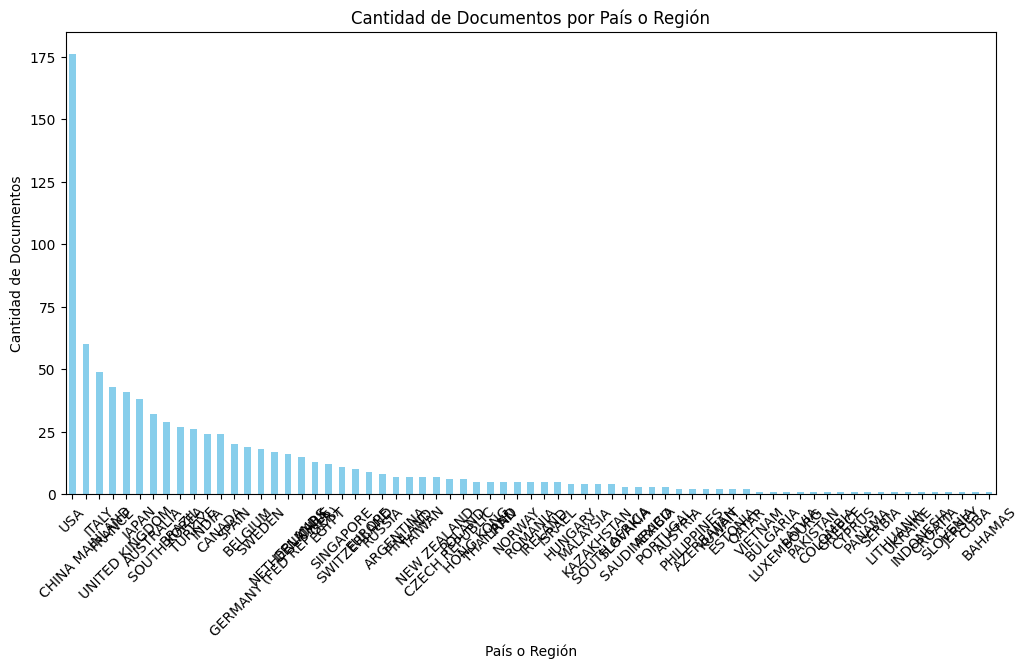

In [ ]:
import matplotlib.pyplot as plt

# Calcular la cantidad de documentos por país o región
documentos_por_pais = df["Country or Region"].value_counts()

plt.figure(figsize=(12, 6))
documentos_por_pais.plot(kind="bar", color="skyblue")
plt.title("Cantidad de Documentos por País o Región")
plt.xlabel("País o Región")
plt.ylabel("Cantidad de Documentos")
plt.xticks(rotation=45)
plt.show()




In [32]:
# Imprimir los datos de la cantidad de documentos por país o región
print("Datos de la cantidad de documentos por país o región:")
for index, value in documentos_por_pais.items():
    print(index, value)


Datos de la cantidad de documentos por país o región:
USA 176
CHINA MAINLAND 60
ITALY 49
FRANCE 43
UNITED KINGDOM 41
JAPAN 38
AUSTRALIA 32
SOUTH KOREA 29
BRAZIL 27
TURKIYE 26
INDIA 24
CANADA 24
SPAIN 20
BELGIUM 19
SWEDEN 18
GERMANY (FED REP GER) 17
NETHERLANDS 16
DENMARK 15
CHILE 13
EGYPT 12
SINGAPORE 11
SWITZERLAND 10
EUROPE 9
RUSSIA 8
ARGENTINA 7
FINLAND 7
TAIWAN 7
NEW ZEALAND 7
CZECH REPUBLIC 6
POLAND 6
HONG KONG 5
THAILAND 5
IRAN 5
NORWAY 5
ROMANIA 5
IRELAND 5
ISRAEL 5
HUNGARY 4
MALAYSIA 4
KAZAKHSTAN 4
SOUTH AFRICA 4
SLOVAKIA 3
SAUDI ARABIA 3
MEXICO 3
PORTUGAL 3
AUSTRIA 2
PHILIPPINES 2
AZERBAIJAN 2
KUWAIT 2
ESTONIA 2
QATAR 2
VIETNAM 1
BULGARIA 1
LUXEMBOURG 1
LATVIA 1
PAKISTAN 1
COLOMBIA 1
GREECE 1
CYPRUS 1
PANAMA 1
SERBIA 1
LITHUANIA 1
UKRAINE 1
INDONESIA 1
CROATIA 1
SLOVENIA 1
JERSEY 1
CUBA 1
BAHAMAS 1


# Gráfico de barras de documentos en revistas de distintos cuartiles (Q1, Q2, Q3, Q4):

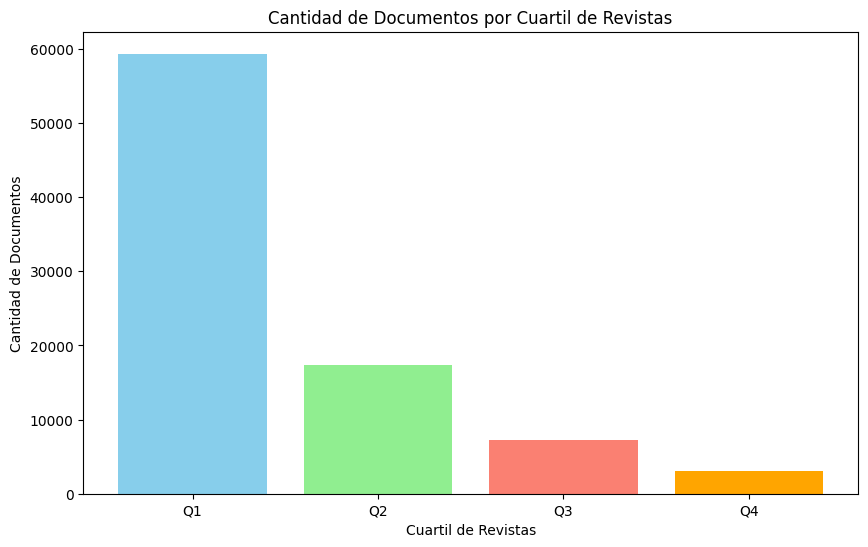

In [ ]:
# Calcular la cantidad de documentos en revistas de distintos cuartiles
cuartiles = ['Q1', 'Q2', 'Q3', 'Q4']
documentos_por_cuartil = [df[f"% Documents in Q{i} Journals"].sum() for i in range(1, 5)]

plt.figure(figsize=(10, 6))
plt.bar(cuartiles, documentos_por_cuartil, color=['skyblue', 'lightgreen', 'salmon', 'orange'])
plt.title("Cantidad de Documentos por Cuartil de Revistas")
plt.xlabel("Cuartil de Revistas")
plt.ylabel("Cantidad de Documentos")
plt.show()


# Gráfico de barras de tipo de acceso (Open Access, Gold, Hybrid, Free to Read):

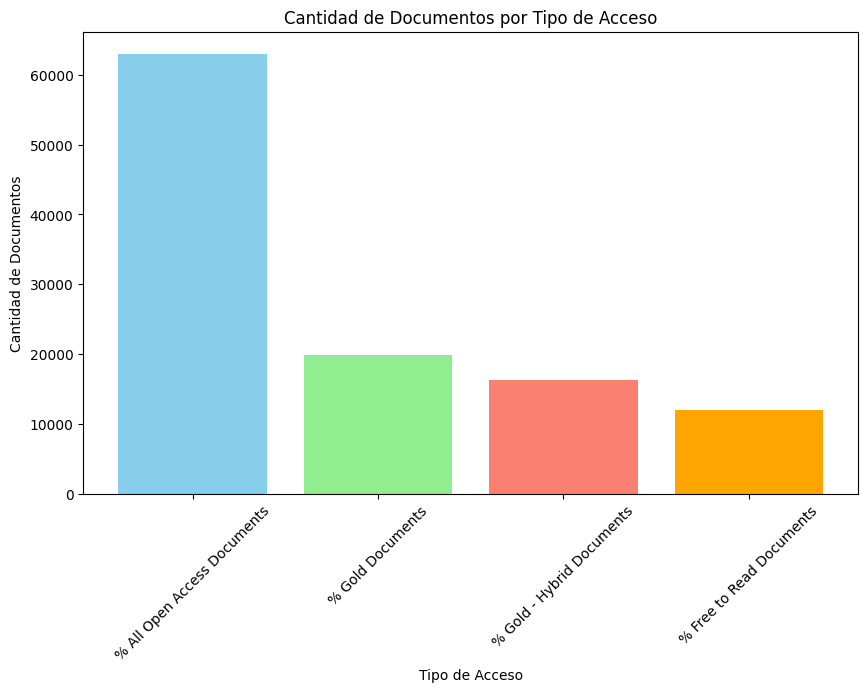

In [ ]:
# Calcular la cantidad de documentos por tipo de acceso
tipos_acceso = ['% All Open Access Documents', '% Gold Documents', '% Gold - Hybrid Documents', '% Free to Read Documents']
documentos_por_tipo_acceso = [df[acceso].sum() for acceso in tipos_acceso]

plt.figure(figsize=(10, 6))
plt.bar(tipos_acceso, documentos_por_tipo_acceso, color=['skyblue', 'lightgreen', 'salmon', 'orange'])
plt.title("Cantidad de Documentos por Tipo de Acceso")
plt.xlabel("Tipo de Acceso")
plt.ylabel("Cantidad de Documentos")
plt.xticks(rotation=45)
plt.show()


# Gráfico de dispersión de citas vs. H-Index:


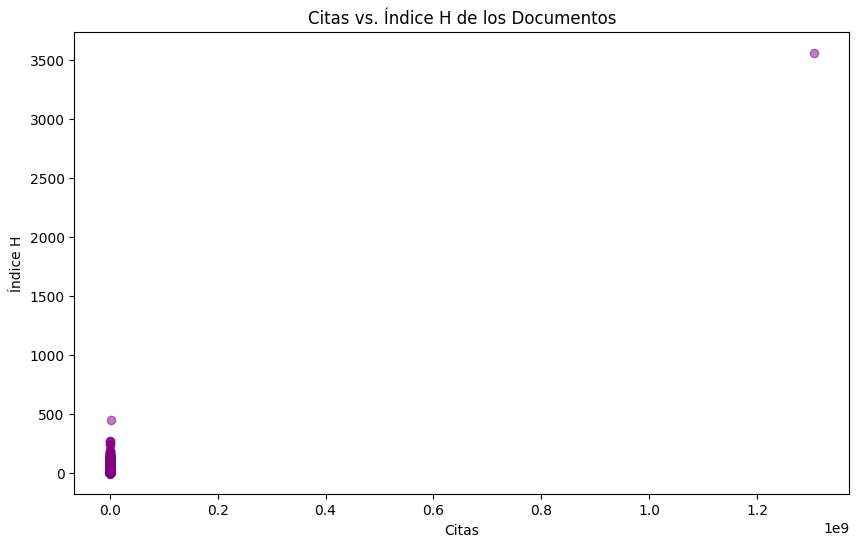

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Times Cited"], df["H-Index"], alpha=0.5, color="purple")
plt.title("Citas vs. Índice H de los Documentos")
plt.xlabel("Citas")
plt.ylabel("Índice H")
plt.show()


In [29]:
# Imprimir los datos de las citas y el índice H
print("Datos del gráfico de dispersión:")
print("Citas:", df["Times Cited"].tolist())
print("Índice H:", df["H-Index"].tolist())


Datos del gráfico de dispersión:
Citas: [1305463262.0, 2879185.0, 1318129.0, 502685.0, 494184.0, 487258.0, 410684.0, 302939.0, 288836.0, 218805.0, 208789.0, 207456.0, 195671.0, 183290.0, 181969.0, 174006.0, 173967.0, 164574.0, 158278.0, 157805.0, 156110.0, 144738.0, 143456.0, 138518.0, 135237.0, 120571.0, 110715.0, 103416.0, 99678.0, 94925.0, 94174.0, 92444.0, 91281.0, 85414.0, 85326.0, 82918.0, 82901.0, 82632.0, 78858.0, 78479.0, 78169.0, 75827.0, 75109.0, 73250.0, 72750.0, 71708.0, 71354.0, 71346.0, 70781.0, 70354.0, 70208.0, 68146.0, 67521.0, 66025.0, 65851.0, 65561.0, 65287.0, 65228.0, 64972.0, 64965.0, 64469.0, 62111.0, 62100.0, 61004.0, 60991.0, 60933.0, 60701.0, 60104.0, 58284.0, 56865.0, 56813.0, 56599.0, 55202.0, 54012.0, 53083.0, 52561.0, 51887.0, 51755.0, 51526.0, 50787.0, 49990.0, 48282.0, 48184.0, 47797.0, 47779.0, 47676.0, 47365.0, 46902.0, 46460.0, 44954.0, 43594.0, 43288.0, 42798.0, 42351.0, 42307.0, 41541.0, 40296.0, 40030.0, 39063.0, 38878.0, 38152.0, 37134.0, 36560.0

# Distribución de Financiación entre Agencias y Regiones

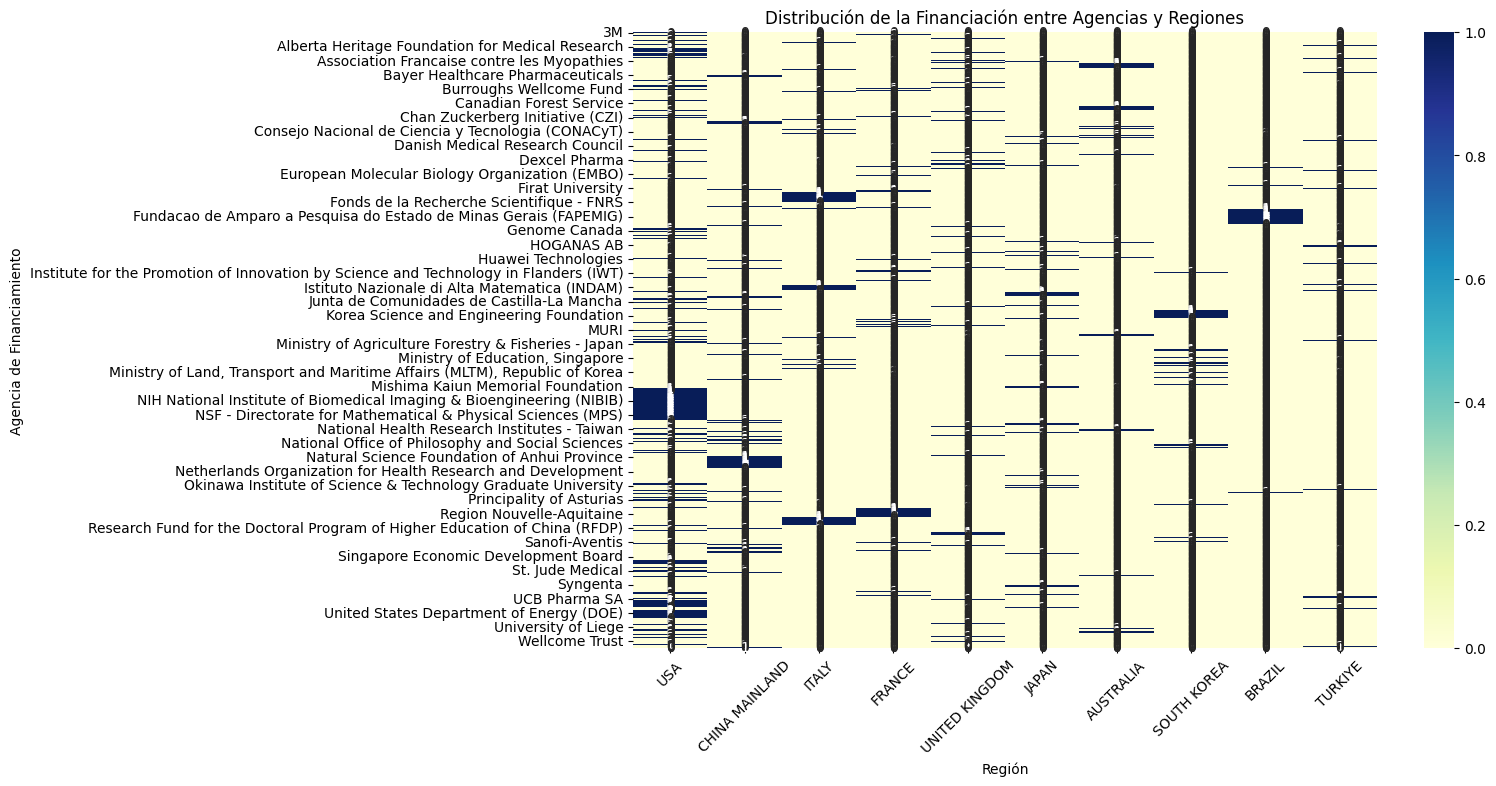

In [27]:
# Filtrar para incluir solo las agencias de financiamiento presentes en el índice de la tabla de contingencia
top_10_organizations = contingency_table.index
common_regions = df["Country or Region"].value_counts().head(10).index
contingency_table = contingency_table.loc[top_10_organizations, common_regions]

# Crear el mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(contingency_table, cmap="YlGnBu", annot=True, fmt="d")
plt.title("Distribución de la Financiación entre Agencias y Regiones")
plt.xlabel("Región")
plt.ylabel("Agencia de Financiamiento")
plt.xticks(rotation=45)
plt.show()



In [28]:
# Filtrar para incluir solo las agencias de financiamiento presentes en el índice de la tabla de contingencia
top_10_organizations = contingency_table.index
common_regions = df["Country or Region"].value_counts().head(10).index
contingency_table = contingency_table.loc[top_10_organizations, common_regions]

# Imprimir los datos de la tabla de contingencia
print("Datos del mapa de calor:")
print(contingency_table)


Datos del mapa de calor:
Country or Region             USA  CHINA MAINLAND  ITALY  FRANCE  \
Name                                                               
3M                              1               0      0       0   
ANPCyT                          0               0      0       0   
ANRS                            0               0      0       1   
AXA Research Fund               0               0      0       1   
AbbVie                          1               0      0       0   
...                           ...             ...    ...     ...   
Xiamen University               0               1      0       0   
Xunta de Galicia                0               0      0       0   
Yuzuncu Yil University          0               0      0       0   
Zagazig University              0               0      0       0   
Zhejiang Sci-Tech University    0               1      0       0   

Country or Region             UNITED KINGDOM  JAPAN  AUSTRALIA  SOUTH KOREA  \
Name       